In [37]:
import numpy as np

In [38]:
import pandas as pd

In [39]:
from sklearn.model_selection import train_test_split, GridSearchCV

In [40]:
from sklearn.svm import SVC

In [41]:
from sklearn.preprocessing import StandardScaler

In [42]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [43]:
import matplotlib.pyplot as plt

In [44]:
#Load Dataset

In [45]:
df = pd.read_csv(r"C:\Users\dell\Downloads\breast-cancer.csv")

In [46]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [47]:
# The diagnosis column has labels "M" (Malignant) and "B" (Benign).
# ML algorithms need numeric labels → we map M → 1, B → 0.

In [48]:
df['diagnosis'] = df['diagnosis'].map({'M' :1, 'B':0})

In [49]:
# The id column is NOT a useful feature — it does not help prediction.
# We drop it to avoid noise.

In [50]:
df = df.drop(columns = ['id'])

In [51]:
#Splits the dataset into:

#X → Features (all columns except diagnosis)
#y → Target (diagnosis)

In [52]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

In [53]:
# SVM is sensitive to feature magnitude.
# StandardScaler scales data to mean = 0, standard deviation = 1.
# Makes SVM training faster and more accurate.

In [54]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [55]:
# Splits dataset into:

# 80% training
# 20% testing

# random_state=42 ensures reproducibility.

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [57]:
# SVC = Support Vector Classifier
# kernel='linear' → Uses a straight line/hyperplane to separate classes
# .fit() trains the model

In [58]:
linear_svm = SVC(kernel='linear')
linear_svm.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [59]:
# Predicts cancer class for test data.

In [60]:
y_pred_linear = linear_svm.predict(X_test)

In [61]:
# Accuracy, Confusion Matrix, Classification Report

In [62]:
# --- Linear SVM Evaluation ---
acc_linear = accuracy_score(y_test, y_pred_linear)
cm_linear = confusion_matrix(y_test, y_pred_linear)
report_linear = classification_report(y_test, y_pred_linear)

print("======================================================")
print("🔍  SVM (Linear Kernel) - Model Evaluation Summary")
print("======================================================\n")

print(f"📌 Accuracy Score: {acc_linear:.4f}\n")

print("📊 Confusion Matrix:")
print("----------------------")
print(cm_linear, "\n")

print("📄 Classification Report:")
print("--------------------------")
print(report_linear)

print("======================================================\n")

🔍  SVM (Linear Kernel) - Model Evaluation Summary

📌 Accuracy Score: 0.9561

📊 Confusion Matrix:
----------------------
[[68  3]
 [ 2 41]] 

📄 Classification Report:
--------------------------
              precision    recall  f1-score   support

           0       0.97      0.96      0.96        71
           1       0.93      0.95      0.94        43

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114




In [63]:
# Confusion Matrix Explained
# [[68  3]
#  [ 2 41]]
# 68 → True Benign
# 3 → Benign predicted as Malignant
# 2 → Malignant predicted as Benign (most dangerous)
# 41 → True Malignant

# Linear SVM accuracy ≈ 95.6%

In [64]:
# Apply Non-Linear Kernel (RBF) & Compare

In [65]:
rbf_svm = SVC(kernel='rbf')
rbf_svm.fit(X_train, y_train)  

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [66]:
# RBF = Radial Basis Function
# Allows curved/non-linear decision boundaries
# Often performs better for complex data

In [67]:
y_pred_rbf = rbf_svm.predict(X_test)

In [68]:
# RBF Accuracy ≈ 97.3%
# Better than linear.

In [69]:
# GridSearchCV Hyperparameter Tuning

In [70]:
param_grid = {
    'C':[0.1,1,10],
    'gamma':['scale','auto'],
    'kernel':['linear','rbf','poly']
}

In [71]:
# C → penalty for misclassification
# gamma → controls influence of points
# kernel → type of model to train

# GridSearch tries all combinations of these.

In [72]:
grid = GridSearchCV(SVC(), param_grid, cv=5)    #run grid search
grid.fit(X_train, y_train)

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf', ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.1


In [73]:
# Uses 5-fold cross-validation
# Trains multiple SVM models
# Selects best based on validation accuracy

In [74]:
best_params = grid.best_params_
best_model = grid.best_estimator_

In [75]:
# Surprisingly, linear kernel becomes best after tuning.

In [76]:
# Test Best Model

In [77]:
y_pred_best = best_model.predict(X_test)
acc_best = accuracy_score(y_test, y_pred_best)

In [78]:
# Best accuracy ≈ 98.2%

In [79]:
# Visualization

In [81]:
# ---- RBF SVM ----
rbf_svm = SVC(kernel='rbf')
rbf_svm.fit(X_train, y_train)

y_pred_rbf = rbf_svm.predict(X_test)

# IMPORTANT: Define the variable
acc_rbf = accuracy_score(y_test, y_pred_rbf)

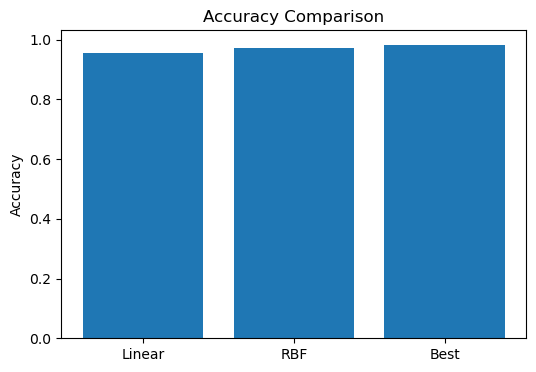

In [82]:
plt.figure(figsize=(6,4))
plt.bar(['Linear','RBF','Best'], [acc_linear, acc_rbf, acc_best])
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()